In [23]:
# prvotni import

import torch
from torch.autograd import grad
from torch.optim.lr_scheduler import ReduceLROnPlateau, StepLR
import sys
from numpy import pi
sys.path.append('../..')

In [24]:
# vlastni import
from src import train, utils
from src import calculus as calc
import src.data.cube_domain as cb
import src.models.mlp_model as mm

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [26]:
ALPHA = 1.0
T_src = 0
L_BOUNDS = [-1.0, -1.0]
U_BOUNDS = [1.0, 1.0]

In [27]:
def pde_residuum(pde_input: torch.Tensor, model: torch.nn.Module) -> torch.Tensor:
    # PDE ztrata:
    pde_output = model(pde_input)
    #print(u_t)
    laplacian = calc.laplacian(pde_input, pde_output, device=device, time_dependant=False)
    return laplacian

def loss_fn(model: torch.nn.Module, domain: cb.CubeDomain):
    int_pts = domain.interior.requires_grad_(True)
    res = pde_residuum(int_pts, model)
    int_loss = torch.mean((res)**2)
    
    left_pts = domain.sides[0][0].requires_grad_(True)
    right_pts = domain.sides[0][1].requires_grad_(True)

    left_out, right_out = model(left_pts), model(right_pts)
    left_loss = torch.mean(left_out**2)
    right_loss = torch.mean((right_out - 1)**2)
    
    top_pts = domain.sides[1][1].requires_grad_(True)
    bot_pts = domain.sides[1][0].requires_grad_(True)
    
    top_out, bot_out = model(top_pts), model(bot_pts)
    
    top_d_dn = calc.dir_derivative(top_pts, top_out, torch.tensor([0, 1], dtype=torch.float32, device=device), False, True)
    bot_d_dn = calc.dir_derivative(bot_pts, bot_out, torch.tensor([0, -1], dtype=torch.float32, device=device), False, True)

    top_loss = torch.mean((top_d_dn - 1)**2)
    bot_loss = torch.mean((bot_d_dn - 1)**2)

    return [int_loss, left_loss, right_loss, top_loss, bot_loss]

In [28]:
model_ctx = mm.ModelContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    input_dim=2,
    output_dim=1,
    layer=[64, 64, 64]
)

model = mm.MLPModel(model_ctx).to(device=device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = ReduceLROnPlateau(optimizer, patience=200, factor=0.75)

In [29]:
domain_ctx = cb.CubeContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    dim=2,
    N_int=5_000,
    N_sides=[(500, 500), (500, 500), (500, 500)],
    int_sampling='Latin',
    device=device,
)

domain = cb.CubeDomain(domain_ctx)

In [30]:
train_ctx = train.TrainingContext(
    model=model,
    optimizer=optimizer,
    domain=domain,
    loss_fn=loss_fn,
    epochs=20_000,
    monitor_lr=True,
)

total_loss_values, component_loss_values = train.train_switch_to_lbfgs(train_ctx, lbfgs_lr=0.05, epochs_with_lbfgs=500)

Loss at epoch 1 is: 3.1964921951293945. Current learing rate: 0.0001 
Loss at epoch 100 is: 1.7468812465667725. Current learing rate: 0.0001 
Loss at epoch 200 is: 0.5621200799942017. Current learing rate: 0.0001 
Loss at epoch 300 is: 0.2858876883983612. Current learing rate: 0.0001 
Loss at epoch 400 is: 0.18765290081501007. Current learing rate: 0.0001 
Loss at epoch 500 is: 0.11060561239719391. Current learing rate: 0.0001 
Loss at epoch 600 is: 0.07134907692670822. Current learing rate: 0.0001 
Loss at epoch 700 is: 0.05326332524418831. Current learing rate: 0.0001 
Loss at epoch 800 is: 0.0451909638941288. Current learing rate: 0.0001 
Loss at epoch 900 is: 0.04471457377076149. Current learing rate: 0.0001 
Loss at epoch 1000 is: 0.0427703894674778. Current learing rate: 0.0001 
Loss at epoch 1100 is: 0.04149802029132843. Current learing rate: 0.0001 
Loss at epoch 1200 is: 0.04336532950401306. Current learing rate: 0.0001 
Loss at epoch 1300 is: 0.04293835535645485. Current lear

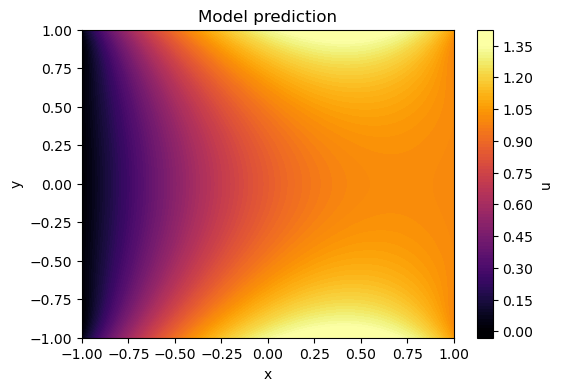

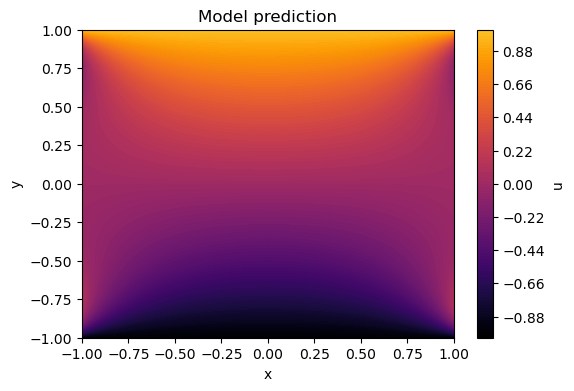

In [35]:
plot_ctx = utils.PlotContext(
    l_bounds=L_BOUNDS,
    u_bounds=U_BOUNDS,
    patches=[],
    titles=["Model prediction"],
    function_names=["u"],
    colour_map='inferno',
    vmin=0,
    vmax=1.35,
    device=device,
    N=100,
    save_img=False
)

utils.plot_function_on_2d_cube([model], plot_ctx)

def top(x: torch.Tensor):
    x.requires_grad_(True)
    out = model(x)
    u_y = grad(out, x, torch.ones_like(out))[0][:, 1]
    return u_y

plot_ctx.vmin=-1
utils.plot_function_on_2d_cube([lambda x: top(x)], plot_ctx)

/home/berva/Projects2/Projects/PINNs/Introduction/notebooks/heat/../../src/utils.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)


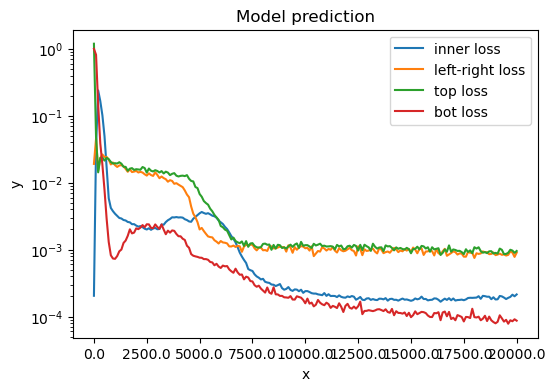

In [32]:
utils.plot_loss_values({"inner loss": component_loss_values[0],
                        "left-right loss": component_loss_values[1],
                        "top loss": component_loss_values[2],
                        "bot loss": component_loss_values[3]}, plot_ctx)

In [ ]:
plot_ctx.vmin = 0
plot_ctx.vmax = 0.01
plot_ctx.titles = ["residuals"]

utils.plot_function_on_2d_cube([lambda x: torch.clamp(torch.abs(pde_residuum(x.requires_grad_(True), model)), 0.0, 0.01)], plot_ctx)

SyntaxError: closing parenthesis ']' does not match opening parenthesis '(' (1015140004.py, line 5)